# Compute a covariance analogous to LSST Y1

The five lens and five source redshift columns and the 26 angular bins match the LSST Y1 layout. Catalog densities are the adapter's explicit SRD forecast choices. The mask selects the M1 3×2pt measurements.

This notebook computes Gaussian (G), super-sample (SSC), connected non-Gaussian
(cNG), and total covariance separately. It then reads the project's supplied
matrix and applies **the same likelihood mask** to both. The comparison concerns
analogous measurements; it is not a reproduction of the supplied covariance.
No likelihood data file is overwritten and no covariance is installed in C.

| Measurement choice | Value |
| --- | --- |
| Dataset | [data/lsst_y1_M1_GGL0.05.dataset](data/lsst_y1_M1_GGL0.05.dataset) |
| Lens / source bins | 5 / 5 |
| Bins per two-point observable | 26, 2.5–900 arcmin |
| Generated entries before cuts | 1,560 |
| Entries after the selected likelihood mask | 959 |

The forecast uses massless neutrinos, linear galaxy bias, zero
magnification/RSD and a spherical-cap footprint.

Gaussian galaxy–galaxy and galaxy–shear spectra include non-Limber
corrections; shear–shear remains Limber. Gaussian NLA/TATT is optional below.

SSC/cNG retain their zero-IA Limber model. SSC uses the isotropic halo
response and cNG the halo trispectrum. Massive-neutrino non-Gaussian terms
are not implemented.

These physical choices differ from the supplied likelihood matrices.
Matching their measurement layout does not establish physical or numerical
equivalence.



The [covariance guide](covariance/README.md) explains survey inputs and how to
start Jupyter. The decomposition follows
[Krause & Eifler, Appendix A](https://arxiv.org/abs/1601.05779) and
[Takada & Hu](https://arxiv.org/abs/1302.6994).
Covariance generation is excluded from the default build. Follow the
[project build steps](README.md#computing_covariances): after activating
Cocoa, unset `IGNORE_COSMOLIKE_LSST_Y1_COVARIANCE` and recompile
this project. Restart the notebook kernel after rebuilding.


In [1]:
import os
from pathlib import Path
import sys

# BLAS stays serial; the compiled CosmoLike loops own the OpenMP workers.
os.environ["OPENBLAS_NUM_THREADS"] = "1"
root = Path(os.environ["ROOTDIR"])
project = root/"projects/lsst_y1"
sys.path.insert(0, str(root/"external_modules/code/cosmolike_core"))
sys.path.insert(0, str(root/"external_modules/code/CAMB"))
sys.path.insert(0, str(project/"interface"))
sys.path.insert(0, str(project/"covariance"))

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from threadpoolctl import threadpool_limits
import cosmolike_lsst_y1_interface as ci
import lsst_y1_covariance as survey
from cosmolike_notebook_utils import covariance as cov
from cosmolike_notebook_utils import plot_covariances as pcov
from cosmolike_notebook_utils.covariance.likelihood import (
    read_likelihood_covariance,
    select_likelihood_entries,
)
from cosmolike_notebook_utils.covariance.forecast import save_forecast

blas_limit = threadpool_limits(limits=1, user_api="blas")
ci.set_omp_threads(n=8)
matplotlib.rcParams["mathtext.fontset"] = "stix"
matplotlib.rcParams["font.family"] = "STIXGeneral"

## Choose the measurement and numerical settings

The default run computes the project's native measurement once at boost 1.
Set `boosts = [1, 2]` to add the numerical comparison below. For galaxy/shear
forecasts, `spaces = ["real", "fourier"]` computes both transformations; the
companion space is illustrative and is not compared to the supplied matrix.
The cluster generator returns the joint real-space measurement only.

`accuracy_boost` multiplies the internal interpolation refinements and
multipole cutoffs in [covariance/default.yaml](covariance/default.yaml).
The default power tables have 11,993 wavenumber samples; boost 2 uses
23,985 while retaining all original nodes. The loop below reinitializes
these tables for each boost. `integration_accuracy` independently selects
96, 128, 256, 512 or 1,024 precomputed GSL nodes per panel at levels 0–4.
Keep the scientific bins, cosmology and CAMB inputs fixed when refining.

The defaults remain **candidate accuracy settings**. Positive definiteness
and a small change in diagonal errors do not establish convergence of all
covariance modes or of Fisher parameter errors. A comparison with the supplied
matrix also mixes physical choices with numerical differences.

The `gaussian` mapping selects the Gaussian spectra separately from numerical
accuracy. Use `ia="NLA", A1=0.6` for an illustrative constant NLA amplitude,
or `ia="TATT", A1=0.6, A2=0.2, B_TA=0.5` for TATT. A list gives one amplitude
per source bin. TATT B modes enter real-space shear covariance. These choices
do not change SSC/cNG or their original mean-subtraction signal.


In [2]:
boosts = [1]
spaces = ['real']
gaussian = {"nonlimber": True, "ia": "none"}
settings = survey.configuration(
    accuracy_boost=boosts[0], gaussian=gaussian,
)
dataset = project/"data/lsst_y1_M1_GGL0.05.dataset"

# These are physical assumptions, not inferred from normalized n(z) columns.
for key in (
    "area_deg2",
    "lens_density_arcmin2",
    "source_density_arcmin2",
    "sigma_e_component",
    "bias",
    "cosmology",
    "accuracy_parameters",
    "gaussian",
):
    print(key, settings[key])

camb_tables = survey.initialize(interface=ci, settings=settings)
ci.set_omp_threads(n=8)


def progress(stage, elapsed):
    """Report completed stages of this calculation, in seconds."""
    print(f"{elapsed:8.2f} s  {stage}")

area_deg2 12300.0
lens_density_arcmin2 [3.6, 3.6, 3.6, 3.6, 3.6]
source_density_arcmin2 [2.0, 2.0, 2.0, 2.0, 2.0]
sigma_e_component [0.26, 0.26, 0.26, 0.26, 0.26]
bias [1.72716, 1.65168, 1.61423, 1.92886, 2.11633]
cosmology {'omegam': 0.3, 'omegab': 0.05, 'H0': 70.0, 'ns': 0.965, 'As_1e9': 2.1, 'w': -1.0, 'w0pwa': -1.0, 'mnu': 0.0, 'AccuracyBoost': 1.0, 'CLAccuracyBoost': 1.0, 'CAMBAccuracyBoost': 1.0, 'kmax': 20.0, 'k_per_logint': 20, 'non_linear_emul': 2, 'lens_potential_accuracy': 1.0, 'halofit_version': 'takahashi'}
accuracy_parameters {'non_gaussian_accuracyboost': 1, 'window_accuracyboost': 1, 'core_accuracyboost': 1, 'power_accuracyboost': 8, 'nonlimber_accuracyboost': 1, 'ell_max': 100000, 'mask_ell_max': 32768, 'ng_ell_intervals': 127, 'response_step': 5e-05, 'nonlimber_lmax': 1000, 'integration_accuracy': 0}
gaussian {'nonlimber': True, 'ia': 'none', 'A1': [0.0, 0.0, 0.0, 0.0, 0.0], 'A2': [0.0, 0.0, 0.0, 0.0, 0.0], 'B_TA': [0.0, 0.0, 0.0, 0.0, 0.0]}


## See the 1h, 2h, 3h and 4h matter trispectra

The **trispectrum** describes the connected four-point correlation of the
matter density in Fourier space. Its four density factors can live in one,
two, three or four halos. The halo model separates their contributions:

| Term | Where the four density factors live |
| --- | --- |
| 1h | All four in one halo. |
| 2h | Two halos, partitioned as 1+3 or 2+2 factors. Both partitions enter. |
| 3h | Three halos, partitioned as 2+1+1 factors. |
| 4h | Four different halos. |

For power-spectrum covariance the wavevectors form
$\mathbf{k},-\mathbf{k},\mathbf{q},-\mathbf{q}$.
The helper averages over the angle between $\mathbf{k}$ and $\mathbf{q}$
in the transverse plane.
Below, choose one redshift and plot the diagonal $q=k$:
$\overline{T}=T_{1h}+T_{2h}^{(1+3)}+T_{2h}^{(2+2)}+T_{3h}+T_{4h}$.
This is a **matter trispectrum before survey projection**, not a diagonal
of the LSST covariance matrix. SSC and Gaussian covariance are separate.

The example uses the initialized cosmology, mass panels and integration
level above. Its 65 wavenumbers sample the plot; they do not change the
integration rule. Internally CosmoLike measures lengths in $c/H_0$.
Convert the input $k$ from $h/\mathrm{Mpc}$ and the output trispectrum
back to $(\mathrm{Mpc}/h)^9$ for the figure.

`halo_terms` retains every unordered $(k,q)$ pair, including off-diagonal
pairs. `T2h_13` and `T2h_22` remain separate arrays; only the plotted 2h
curve combines them. The signed logarithmic y axis preserves negative
contributions and is linear within $|\overline{T}|<1\,(\mathrm{Mpc}/h)^9$.
Changing `halo_redshift` below explores another epoch without rerunning CAMB.


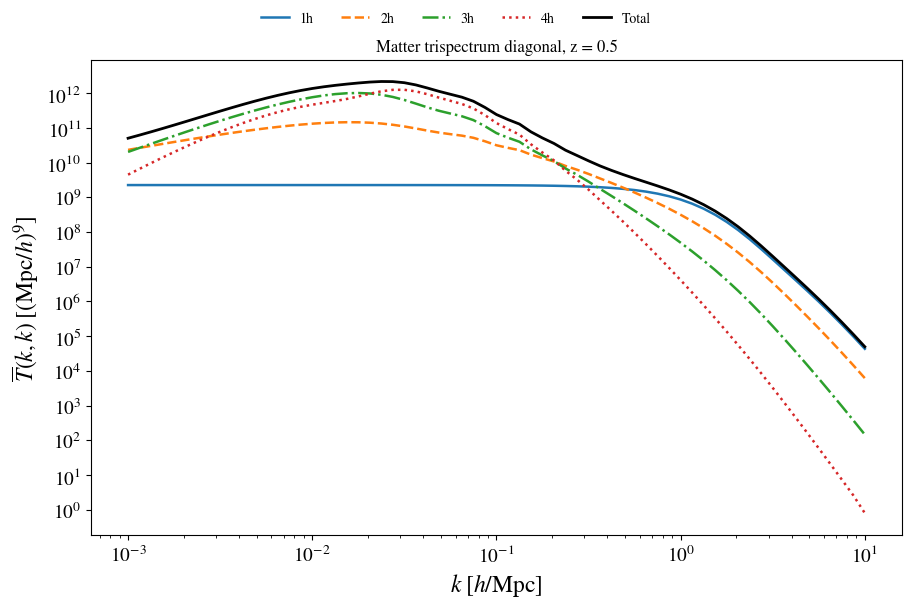

In [3]:
halo_redshift = 0.5
halo_scale_factor = 1.0/(1.0+halo_redshift)
k_hmpc = np.geomspace(start=1.e-3, stop=10.0, num=65)

# c/H0 is 2997.92458 Mpc/h: the factor h is already in the length unit.
# A trispectrum has nine powers of length, whereas power has three.
cover_h0_mpc_over_h = 2997.92458
k_core = k_hmpc*cover_h0_mpc_over_h
halo_terms = cov.halo_trispectrum(
    interface=ci,
    a=halo_scale_factor,
    k=k_core,
    lnm_edges=settings["lnm_edges"],
    accuracy_boost=settings["accuracy_boost"],
    mnu=settings["cosmology"]["mnu"],
    integration_accuracy=settings["integration_accuracy"],
)
terms_mpc_over_h9 = halo_terms["terms"]*cover_h0_mpc_over_h**9

# The five rows distinguish the two possible two-halo partitions.
# Every row uses the same triangular ordering of wavenumber pairs.
T1h = terms_mpc_over_h9[0]
T2h_13 = terms_mpc_over_h9[1]
T2h_22 = terms_mpc_over_h9[2]
T3h = terms_mpc_over_h9[3]
T4h = terms_mpc_over_h9[4]
T2h = T2h_13+T2h_22

# Equal pair indices select q=k, in the order of the original k grid.
diagonal_pairs = halo_terms["first"] == halo_terms["second"]
halo_diagonal = {
    "1h": T1h[diagonal_pairs],
    "2h": T2h[diagonal_pairs],
    "3h": T3h[diagonal_pairs],
    "4h": T4h[diagonal_pairs],
}
pcov.plot_trispectrum_terms(
    k_hmpc=k_hmpc,
    components=halo_diagonal,
    redshift=halo_redshift,
)


## Compute G, SSC, cNG and their sum

G describes covariance made from pairs of two-point spectra, including
catalog shot noise and shape noise. SSC couples measurements through a
background density fluctuation larger than the footprint. cNG is the remaining
connected four-point contribution in the adopted halo model.

Angular bins are consecutive within each observable. The Fourier companion
uses one E-mode row per source pair, with integer multipoles weighted by
$2\ell+1$ inside each band. The Fourier likelihood evaluates its mean spectrum
at logarithmic band centers; the generated covariance instead averages integer
modes within bands. It is therefore an analogous bandpower calculation.

Each computation retains internal cross-bin spectra even when the corresponding
observable is absent from the measured vector. The loop below changes only
numerical resolution, and stores all physical components at each requested boost.

In [4]:
# Each space uses its own projection. Changing the boost refines tables
# while preserving cosmology, observable ordering and measured bins.
results = {}
for space in spaces:
    if space not in ['real', 'fourier']:
        raise ValueError("Choose a measurement space supported by this adapter")
    results[space] = {}
    for boost in boosts:
        refined = dict(settings)
        refined.update(cov.covariance_accuracy(
            accuracy_boost=boost, **settings["accuracy_parameters"],
        ))
        # Reinstall the power tables at this boost, so their k grid
        # is refined along with the covariance integration tables.
        camb_tables = survey.initialize(interface=ci, settings=refined)
        ci.set_omp_threads(n=8)
        print(space, "accuracy boost", boost)
        results[space][boost] = survey.compute(
            interface=ci, settings=refined, space=space, progress=progress,
        )

native_space = 'real'
forecast = results[native_space][boosts[-1]]
print("Full covariance shape:", forecast["total"].shape)

real accuracy boost 1


    2.11 s  all_pairs_gaussian_spectra


    3.52 s  angular_and_mask_geometry


    7.67 s  gaussian_blocks


    7.90 s  observable_signal


...

  157.55 s  Matter shell 577/672


  165.22 s  Matter shell 609/672


  172.93 s  Matter shell 641/672


  180.26 s  shared_halo_response_and_trispectrum


  180.50 s  ssc_and_connected_projection
  180.51 s  total
Full covariance shape: (1560, 1560)


## Apply the project's likelihood cuts

The supplied mask selects measurements, so the same selection must act on
both axes of G, SSC, cNG and their sum. The saved `indices` preserve the original
file positions after compaction. Probe labels refer to contiguous groups in the
uncut likelihood vector, including any measured-pair exclusions.

The reader adds the Gaussian and combined non-Gaussian columns of legacy
CosmoCov files. It does not guess how that combined column divides into SSC
and cNG. The supplied total appears in the upper triangle of the plot and
the newly computed total in the lower triangle. Each uses its own diagonal
for correlation normalization; differences here are **not** a numerical
convergence test.

Supplied file size: 1560
Retained comparison size: 959
Mask: lsst_y1_M1_GGLOLAP0.05.mask


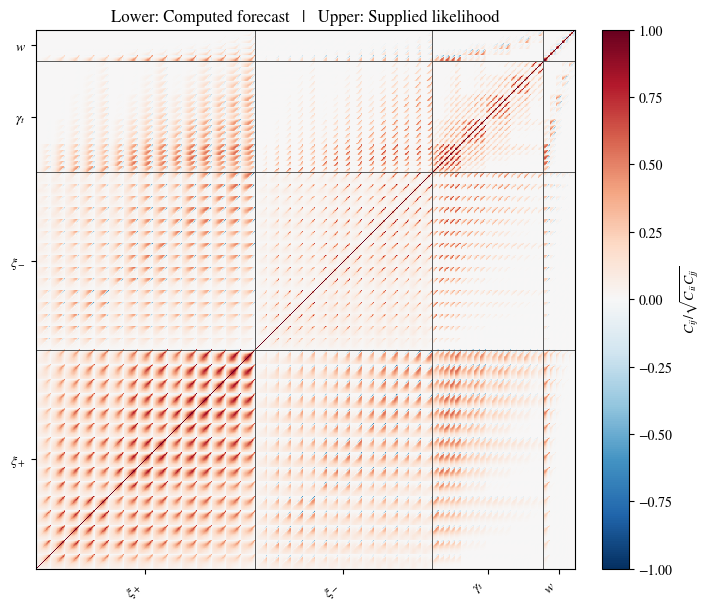

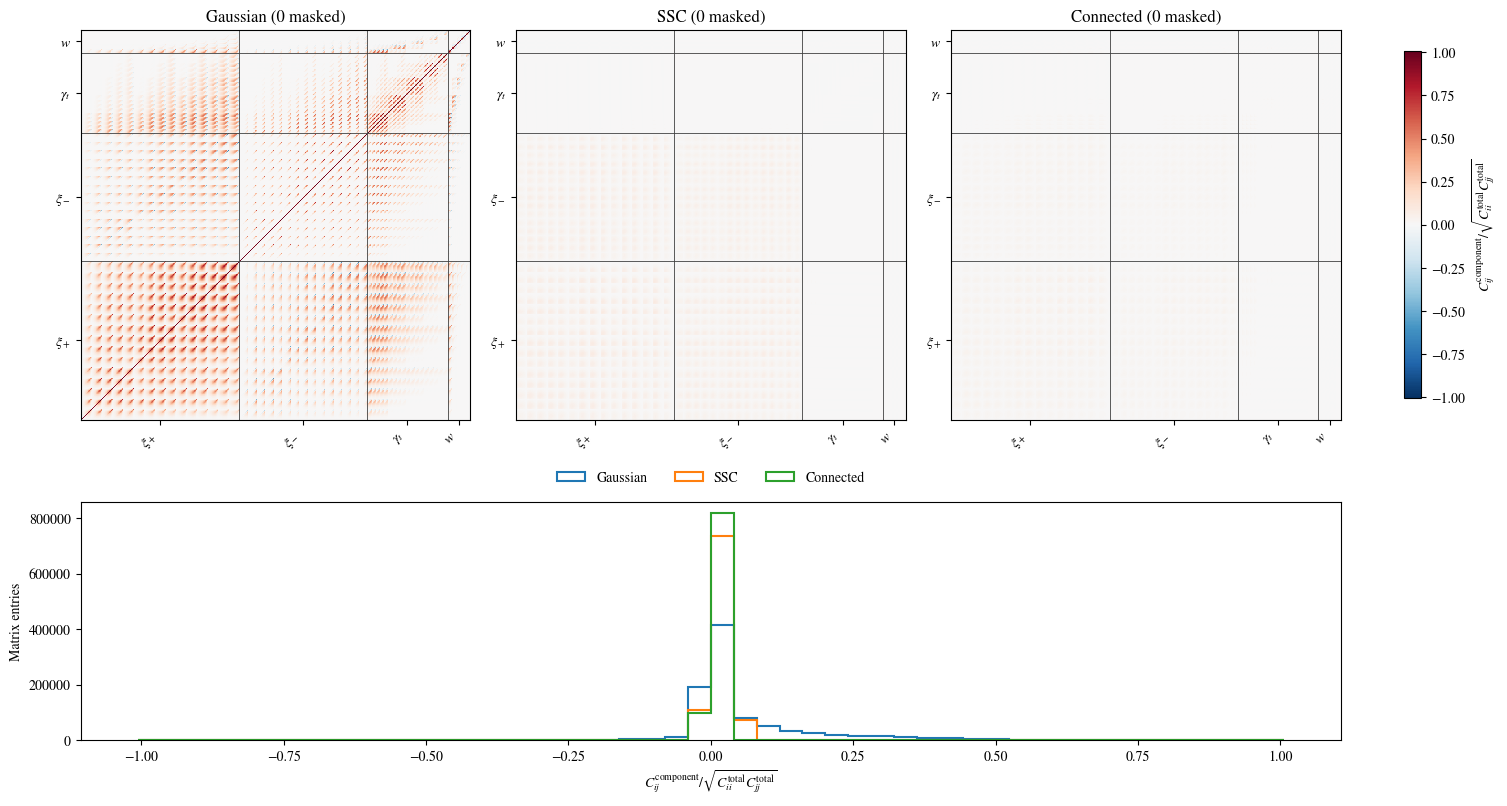

total positive definite: True minimum correlation eigenvalue: 0.005927663511505591
supplied positive definite: True minimum correlation eigenvalue: 0.00623910182394709


In [5]:
supplied = read_likelihood_covariance(dataset=dataset)
block_sizes = [390, 390, 650, 130]
block_labels = ['$\\xi_+$', '$\\xi_-$', '$\\gamma_t$', '$w$']
selected = select_likelihood_entries(
    forecast=forecast,
    supplied=supplied,
    block_sizes=block_sizes,
    block_labels=block_labels,
)
print("Supplied file size:", supplied["file_size"])
print("Retained comparison size:", len(selected["indices"]))
print("Mask:", Path(supplied["mask_file"]).name)

pcov.plot_correlation(
    covariance=selected["total"],
    covariance_ref=selected["supplied"],
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    labels=("Computed forecast", "Supplied likelihood"),
)
pcov.plot_covariance_components(
    total=selected["total"],
    components={
        "Gaussian": selected["gaussian"],
        "SSC": selected["ssc"],
        "Connected": selected["cng"],
    },
    block_sizes=selected["block_sizes"],
    block_labels=selected["block_labels"],
    normalization="diagonal",
)

for label in ("total", "supplied"):
    modes = cov.covariance_modes(matrix=selected[label])
    print(label, "positive definite:", modes["positive_definite"],
          "minimum correlation eigenvalue:", modes["correlation_eigenvalues"][0])

## Check changes with accuracy boost

With two or more boosts, the next cell compares the *computed* matrices after
the same likelihood cuts. The highest tested boost is a comparison reference.
Generalized eigenvalues solve $C_bv=\lambda C_{m ref}v$ and bound variance
ratios for every linear combination of retained measurements. The reported
maximum departure from one is a fraction; 0.01 means 1%.

The error-bar panel selects the first source auto-correlation. It shows the
percent change of $\sqrt{C_{ii}}$ relative to the highest boost. This illustrates
why convergence needs more than diagonal agreement. Refine quadrature separately
at fixed boost, and eventually check marginalized Fisher errors and Figure of
Merit. No matrix here has its eigenvalues clipped or its diagonal repaired.

The split-triangle layout follows [Friedrich et al., Fig. 6](https://arxiv.org/abs/2012.08568).
Component maps adapt [Barreira, Krause & Schmidt, Fig. 1](https://arxiv.org/abs/1807.04266).

In [6]:
if len(boosts) == 1:
    print("Set boosts = [1, 2] above and rerun to compare numerical accuracy.")
else:
    for boost in boosts:
        current = select_likelihood_entries(
            forecast=results[native_space][boost],
            supplied=supplied,
            block_sizes=block_sizes,
            block_labels=block_labels,
        )
        change = cov.compare_covariances(
            matrix=current["total"], reference=selected["total"],
        )
        print(boost, "maximum fractional variance change:",
              change["maximum_fractional_variance_change"])

    # The first observable is the first source auto-correlation, with
    # all its angular bins or Fourier bands consecutive in the full vector.
    nbin = 26
    reference = forecast["total"][:nbin, :nbin]
    curves = {}
    for boost in boosts[:-1]:
        curves[f"Boost {boost} / {boosts[-1]}"] = (
            results[native_space][boost]["total"][:nbin, :nbin]
        )
    coordinate = forecast["coordinate"]
    pcov.plot_covariance_diagonal(
        theta_arcmin=coordinate,
        covariances=curves,
        panel_labels=['$\\xi_+$'],
        covariance_ref=reference,
        coordinate_label='$\\ell$' if native_space == "fourier" else '$\\theta\\;[\\mathrm{arcmin}]$',
    )

Set boosts = [1, 2] above and rerun to compare numerical accuracy.


## Inspect the C++ notebook interface

The compiled wrappers take vectors, matrices and cubes with named physical
axes. Python converts NumPy inputs into owned Armadillo arrays; notebook copies
are intentional. Whole Gaussian matrices and individual projection, halo and
response components are available for independent experiments. The help text
gives dimensions and units.

In [7]:
help(ci.covariance_gaussian_fourier)
help(ci.covariance_project)
help(ci.covariance_halo_response)

Help on built-in function covariance_gaussian_fourier in module cosmolike_lsst_y1_interface:

covariance_gaussian_fourier(...) method of builtins.PyCapsule instance
    covariance_gaussian_fourier(spectra: object, noise: object, pairs: object, operators: object, ell_min: int, area_sr: float) -> Numpy.ndarray[numpy.float64]
    
    Compute a Gaussian bandpower matrix from supplied field spectra.
    
    spectra[ell,field,field] contains observed signal on consecutive integer
    multipoles starting at ell_min>=0. noise[field] is independent white
    shot/shape power. pairs[observable,2] contains field IDs (A,B).
    operators[band,ell] supplies normalized band weights; the supplied bands
    may overlap. area_sr is the common survey area in steradians.
    Use float64 arrays and int32 pairs. Internal crossed spectra
    are required even when excluded from the measured bandpower vector.
    
    Returns an owned symmetric [nobservable*nband,nobservable*nband] matrix,
    with bands i

## Save the calculation

The archives retain each physical component, ordering, physical assumptions and
resolved accuracy settings. The separate likelihood-selection archive contains
the compact matrices, original entry indices and the supplied total used in the
plot. Only files in `covariance/` are written; the supplied files in `data/`
remain unchanged. Running this cell again replaces the computed archives.

In [8]:
for space in spaces:
    save_forecast(
        result=results[space][boosts[-1]],
        filename=project/"covariance"/f"forecast_{space}.npz",
    )
np.savez(file=project/"covariance/forecast_camb.npz", **camb_tables)
np.savez(
    file=project/"covariance/forecast_likelihood_selection.npz",
    **selected,
    dataset=str(dataset.relative_to(project)),
    accuracy_boost=boosts[-1],
)
print("Saved covariance components and likelihood selection.")

Saved covariance components and likelihood selection.
